--- ข้อมูลเบื้องต้น ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 

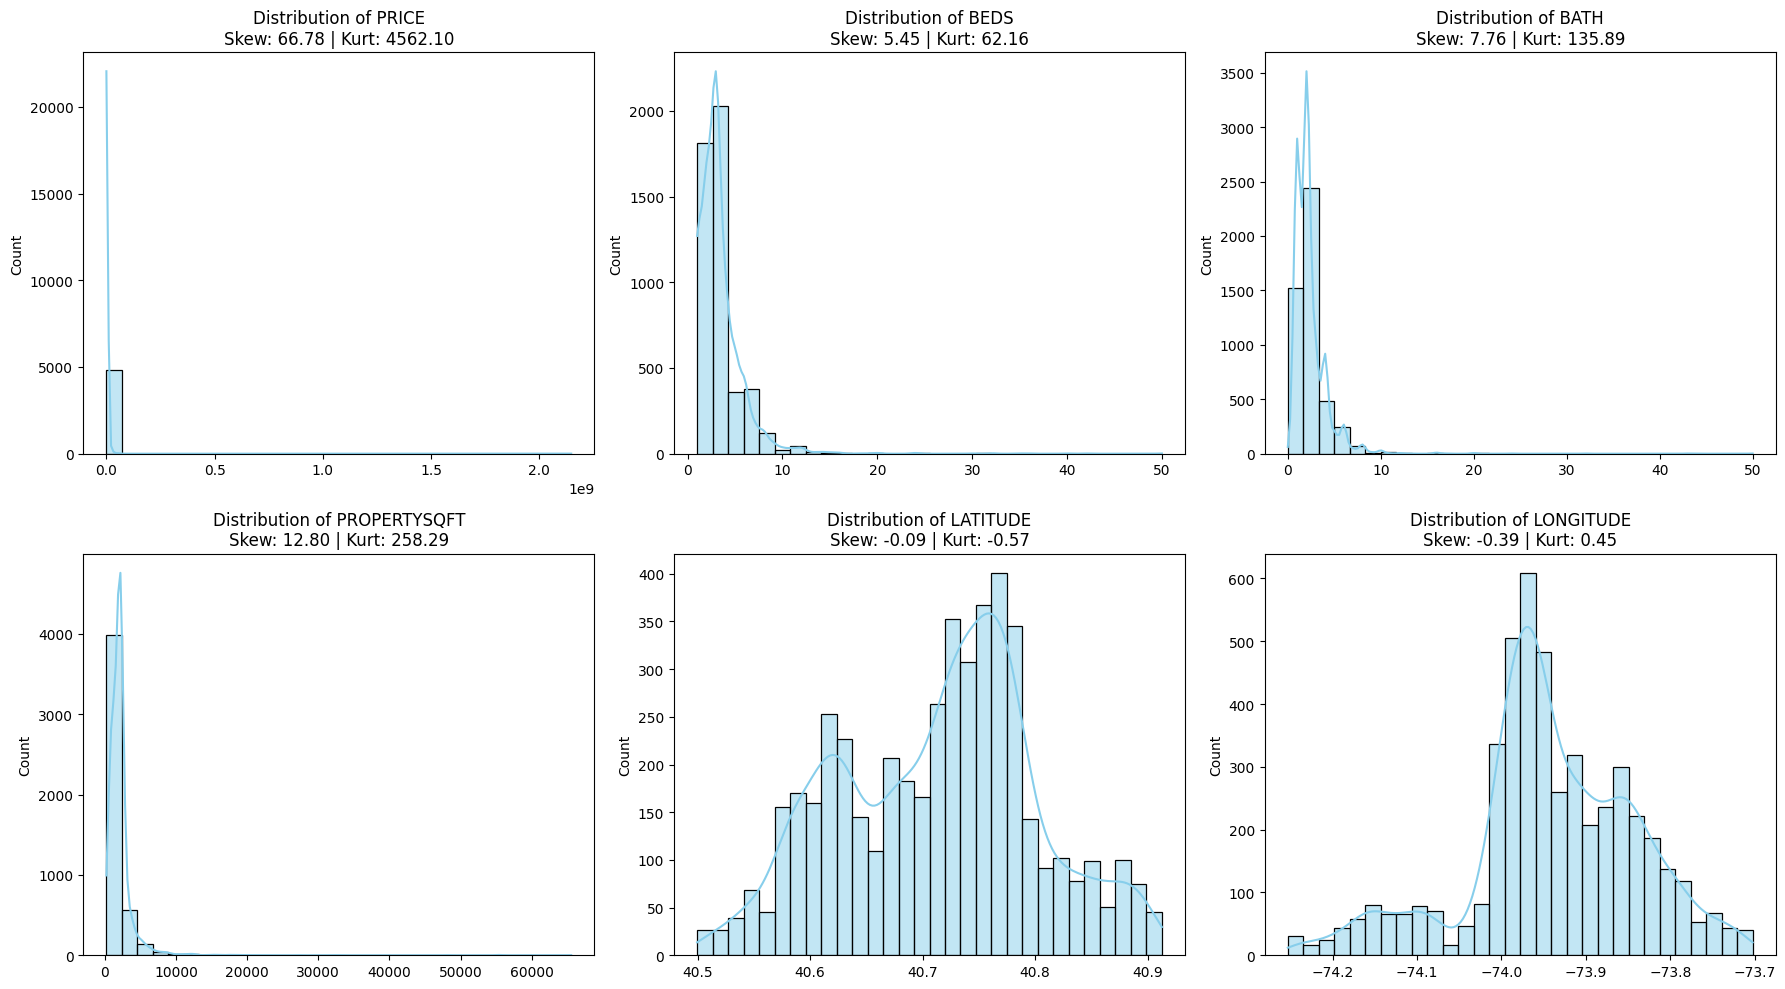

Column (After)  |   Skewness |   Kurtosis
------------------------------------------
LOG_PRICE       |       0.47 |       1.34
LOG_SQFT        |      -0.43 |       0.21
BEDS            |       1.25 |       2.13
BATH            |       1.29 |       1.64
LATITUDE        |      -0.08 |      -0.58
LONGITUDE       |      -0.41 |       0.40


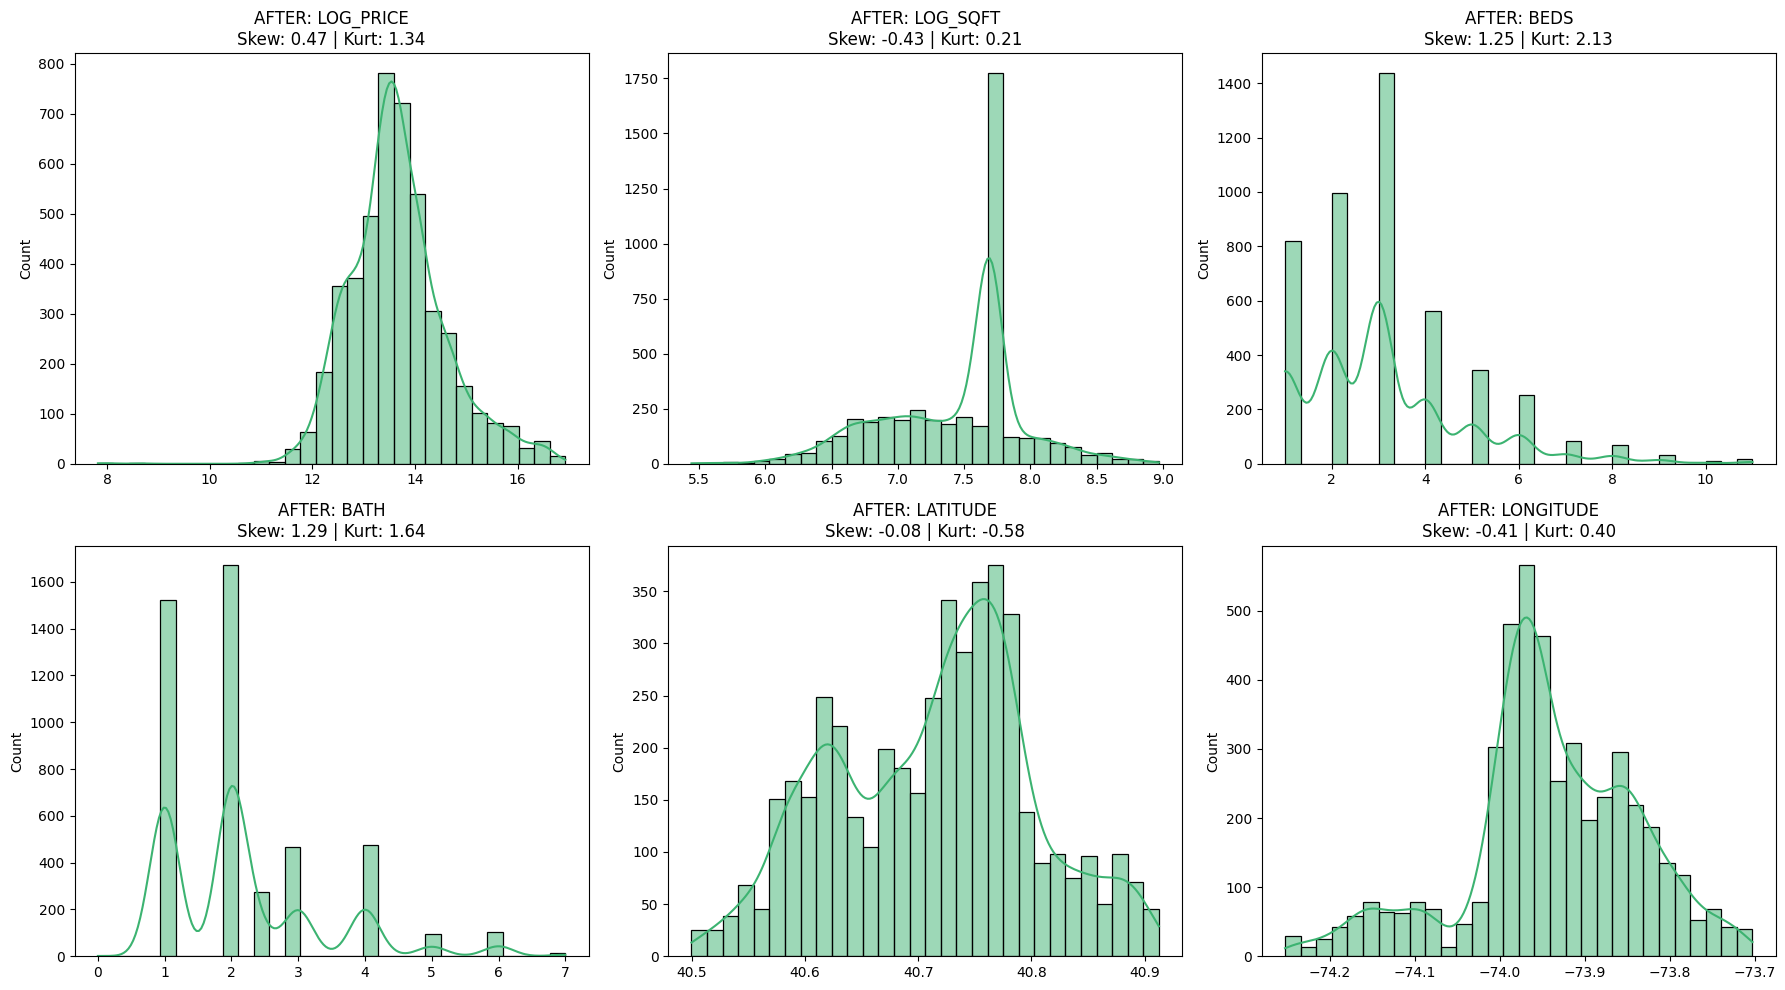

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. โหลดข้อมูล
df = pd.read_csv('../data/NY-House-Dataset.csv')

# 2. ดูภาพรวมของข้อมูล
print("--- ข้อมูลเบื้องต้น ---")
print(df.info())

# 3. ดูสถิติพื้นฐาน (ราคา, จำนวนห้องนอน, พื้นที่)
print("\n--- สถิติพื้นฐานของตัวเลข ---")
print(df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].describe())

# 4. ตรวจสอบค่าว่าง
print("\n--- จำนวนค่าว่างในแต่ละ Column ---")
print(df.isnull().sum())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 1. เลือกคอลัมน์ที่ต้องการวิเคราะห์
num_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']

# 2. เตรียมพื้นที่สำหรับวาดกราฟ (คำนวณแถวอัตโนมัติ: 3 คอลัมน์ต่อแถว)
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(18, 5 * n_rows))

# หัวข้อรายงานใน Console
print(f"{'Column':<15} | {'Skewness':>10} | {'Kurtosis':>10}")
print("-" * 42)

# 3. วนลูปเพื่อวาดกราฟและคำนวณค่าสถิติ
for i, col in enumerate(num_cols):
    # ตรวจสอบว่ามีคอลัมน์นี้อยู่ใน DataFrame จริงหรือไม่
    if col in df.columns:
        # ดึงข้อมูลและลบค่าว่าง (NaN) ออกเพื่อความแม่นยำในการคำนวณ
        data = df[col].dropna()
        
        # คำนวณค่า Skewness และ Kurtosis
        s = skew(data)
        k = kurtosis(data)
        
        # ปริ้นค่าสถิติออกมาดู
        print(f"{col:<15} | {s:>10.2f} | {k:>10.2f}")
        
        # วาดกราฟ Histogram + KDE
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(data, kde=True, color='skyblue', bins=30)
        
        # ใส่ชื่อกราฟพร้อมค่าสถิติ
        plt.title(f'Distribution of {col}\nSkew: {s:.2f} | Kurt: {k:.2f}', fontsize=12)
        plt.xlabel('')
        plt.ylabel('Count')

# ปรับระยะห่างระหว่างกราฟ
plt.tight_layout()
plt.show()
plt.show()







--- ข้อมูลเบื้องต้น ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3709 entries, 0 to 3708
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  3709 non-null   object 
 1   TYPE                         3709 non-null   object 
 2   PRICE                        3709 non-null   int64  
 3   BEDS                         3709 non-null   int64  
 4   BATH                         3709 non-null   float64
 5   PROPERTYSQFT                 3709 non-null   float64
 6   ADDRESS                      3709 non-null   object 
 7   STATE                        3709 non-null   object 
 8   MAIN_ADDRESS                 3709 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  3709 non-null   object 
 10  LOCALITY                     3709 non-null   object 
 11  SUBLOCALITY                  3709 non-null   object 
 12  STREET_NAME                  3709 non-null   object 

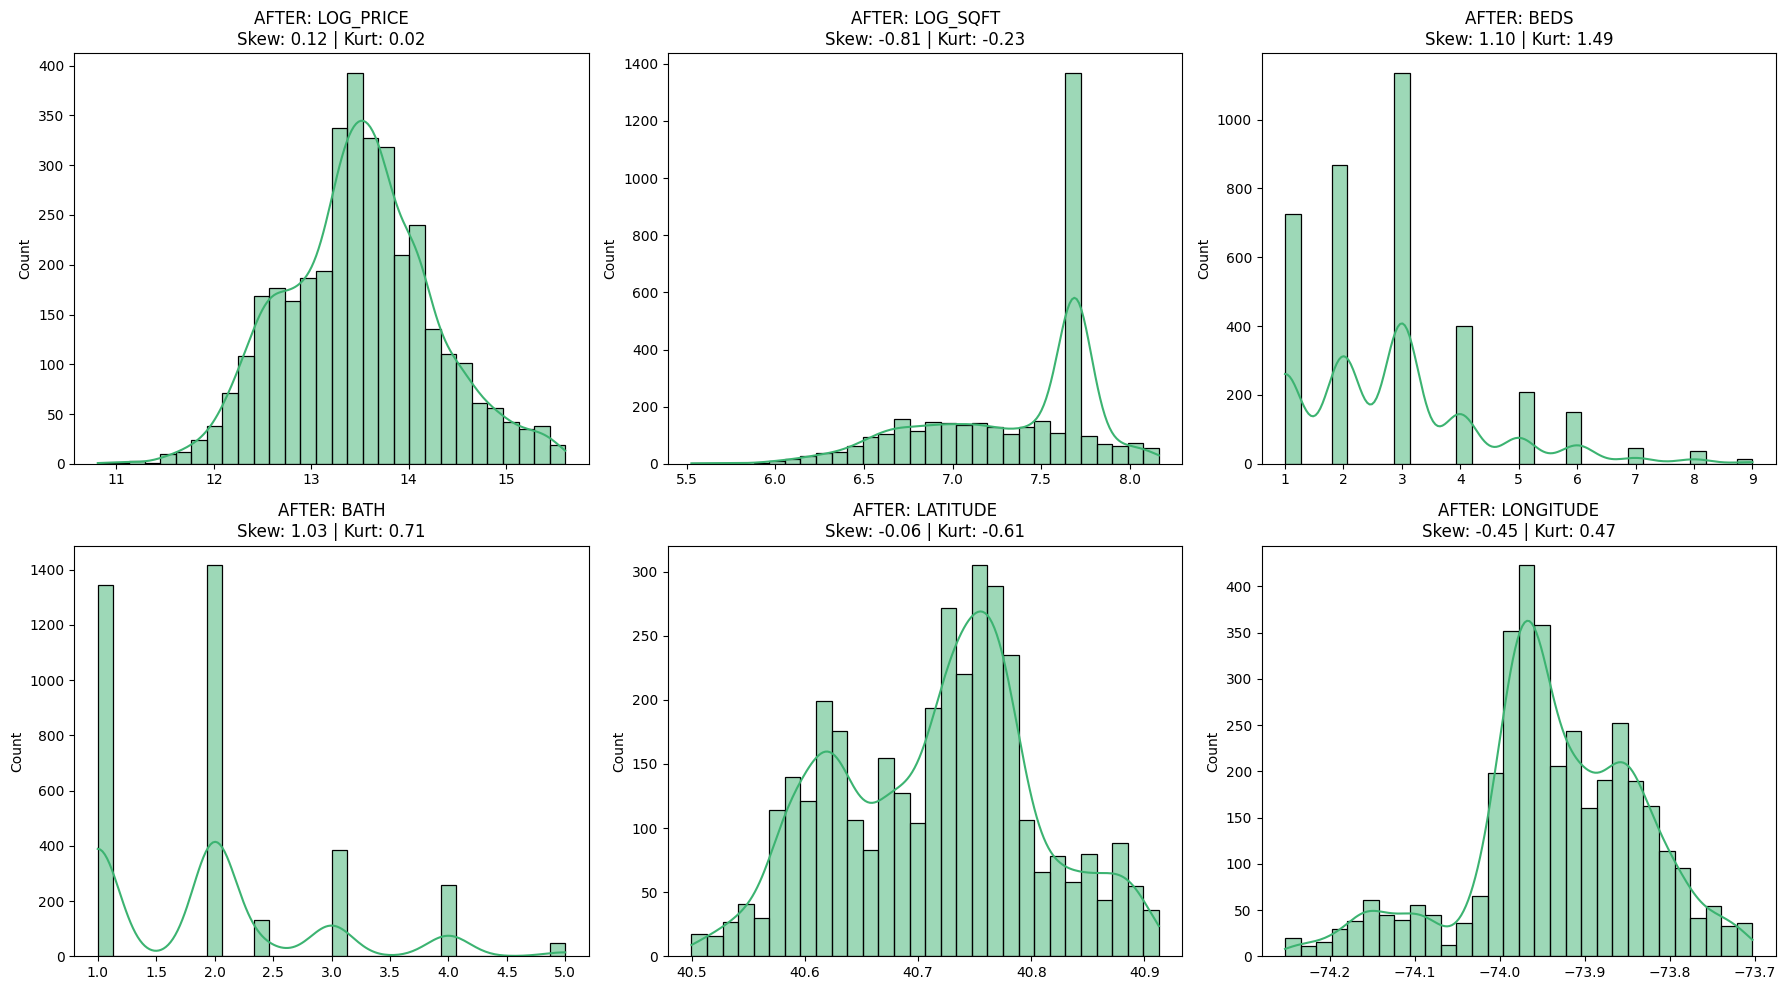

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. โหลดข้อมูล
df = pd.read_csv('../data/NY_House_Cleaned.csv')

# 2. ดูภาพรวมของข้อมูล
print("--- ข้อมูลเบื้องต้น ---")
print(df.info())

# 3. ดูสถิติพื้นฐาน (ราคา, จำนวนห้องนอน, พื้นที่)
print("\n--- สถิติพื้นฐานของตัวเลข ---")
print(df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].describe())

# 4. ตรวจสอบค่าว่าง
print("\n--- จำนวนค่าว่างในแต่ละ Column ---")
print(df.isnull().sum())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# --- ส่วนที่ 1: ขั้นตอนการ Clean และ Transform ---
df_clean = df.copy()

# 1.1 ตัด Outliers ที่เปอร์เซ็นต์ไทล์ที่ 99 (ลบ 1% ที่ค่าโด่งผิดปกติออก)
cols_to_clip = ['PRICE', 'PROPERTYSQFT', 'BEDS', 'BATH']
for col in cols_to_clip:
    upper_limit = df_clean[col].quantile(0.99)
    df_clean = df_clean[df_clean[col] <= upper_limit]

# 1.2 Transformation: ใช้ Log1p เพื่อลดความเบ้ (Skewness)
# เราจะสร้างคอลัมน์ใหม่เพื่อเก็บค่าที่ Transform แล้ว
df_clean['LOG_PRICE'] = np.log1p(df_clean['PRICE'])
df_clean['LOG_SQFT'] = np.log1p(df_clean['PROPERTYSQFT'])

# --- ส่วนที่ 2: การแสดงผล (สอดคล้องกับโค้ดที่คุณใช้) ---
# เลือกคอลัมน์ที่จะนำมาโชว์ผลลัพธ์ "หลังทำ"
after_cols = ['LOG_PRICE', 'LOG_SQFT', 'BEDS', 'BATH', 'LATITUDE', 'LONGITUDE']

n_cols = 3
n_rows = (len(after_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(18, 5 * n_rows))

print(f"{'Column (After)':<15} | {'Skewness':>10} | {'Kurtosis':>10}")
print("-" * 42)

for i, col in enumerate(after_cols):
    if col in df_clean.columns:
        data = df_clean[col].dropna()
        s = skew(data)
        k = kurtosis(data)
        
        print(f"{col:<15} | {s:>10.2f} | {k:>10.2f}")
        
        plt.subplot(n_rows, n_cols, i + 1)
        # เปลี่ยนเป็นสีเขียว (mediumseagreen) เพื่อให้เห็นความต่างจากข้อมูลเดิม
        sns.histplot(data, kde=True, color='mediumseagreen', bins=30)
        
        plt.title(f'AFTER: {col}\nSkew: {s:.2f} | Kurt: {k:.2f}', fontsize=12)
        plt.xlabel('')
        plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
# นับจำนวนแถวที่ซ้ำกันทั้งหมด
duplicate_count = df.duplicated().sum()
print(f"พบข้อมูลซ้ำทั้งหมด: {duplicate_count} แถว")

# แสดงแถวที่ซ้ำออกมาดู (เปรียบเทียบตัวต้นฉบับกับตัวที่ซ้ำ)
duplicates = df[df.duplicated(keep=False)]
print(duplicates.head())

พบข้อมูลซ้ำทั้งหมด: 0 แถว
Empty DataFrame
Columns: [BROKERTITLE, TYPE, PRICE, BEDS, BATH, PROPERTYSQFT, ADDRESS, STATE, MAIN_ADDRESS, ADMINISTRATIVE_AREA_LEVEL_2, LOCALITY, SUBLOCALITY, STREET_NAME, LONG_NAME, FORMATTED_ADDRESS, LATITUDE, LONGITUDE, SUBLOCALITY_CLEAN]
Index: []


In [43]:

df = pd.read_csv('../data/NY_House_Cleaned.csv')
#df = pd.read_csv('../data/NY-House-Dataset.csv')
subset_cols = ['LATITUDE', 'LONGITUDE', 'PROPERTYSQFT', 'BEDS', 'BATH', 'TYPE', 'PRICE', 'ADDRESS', 'STATE']
dup_properties = df.duplicated(subset=subset_cols).sum()
duplicate_rows = df[df.duplicated(subset=subset_cols, keep=False)]

duplicate_rows = duplicate_rows.sort_values(by=['LATITUDE', 'LONGITUDE', 'PROPERTYSQFT', 'BEDS', 'BATH', 'TYPE', 'PRICE', 'ADDRESS', 'STATE'])

display(duplicate_rows[subset_cols + ['LATITUDE', 'LONGITUDE', 'PROPERTYSQFT', 'BEDS', 'BATH', 'TYPE', 'PRICE', 'ADDRESS',  'STATE']]) # เพิ่ม PRICE/TYPE เข้าไปดูด้วยเพื่อเปรียบเทียบ
print(f"พบประกาศที่น่าจะเป็นบ้านหลังเดียวกันซ้ำซ้อน: {dup_properties} รายการ")

duplicate_count = df.duplicated().sum()
print(f"พบข้อมูลซ้ำทั้งหมด: {duplicate_count} แถว")


,LATITUDE,LONGITUDE,PROPERTYSQFT,BEDS,BATH,TYPE,PRICE,ADDRESS,STATE,LATITUDE,LONGITUDE,PROPERTYSQFT,BEDS,BATH,TYPE,PRICE,ADDRESS,STATE


พบประกาศที่น่าจะเป็นบ้านหลังเดียวกันซ้ำซ้อน: 0 รายการ
พบข้อมูลซ้ำทั้งหมด: 0 แถว


In [12]:
import pandas as pd

# 1. โหลดข้อมูล
df = pd.read_csv('../data/NY_House_Cleaned.csv')

# 2. สร้าง Function เพื่อแยกประเภทข้อมูล (Type) คล้ายในภาพ
def get_data_type(series):
    if pd.api.types.is_numeric_dtype(series):
        if series.nunique() <= 2:
            return "Binary"
        return "Numeric"
    elif pd.api.types.is_datetime64_any_dtype(series):
        return "Ordinal/Date"
    else:
        if series.nunique() <= 10:
            return "Nominal (Category)"
        return "Text/String"

# 3. สร้าง List ของข้อมูลสรุป
summary_list = []
for col in df.columns:
    summary_list.append({
        "ตัวแปร": col,
        "ความหมาย (เบื้องต้น)": f"ข้อมูลเกี่ยวกับ {col}", # ปรับแก้คำอธิบายที่นี่
        "จำนวนค่าที่ไม่ซ้ำ (Unique)": df[col].nunique(),
        "Type": get_data_type(df[col]),
        "ตัวอย่างข้อมูล": df[col].iloc[0]
    })

# 4. แปลงเป็น DataFrame และแสดงผล
data_dictionary = pd.DataFrame(summary_list)

# แสดงตาราง
print(data_dictionary.to_string(index=False))

# (Option) บันทึกออกมาเป็นไฟล์ Excel เพื่อเอาไปทำรายงานต่อ
data_dictionary.to_excel("Data_Dictionary_NY_Housing.xlsx", index=False)

                     ตัวแปร                        ความหมาย (เบื้องต้น)  จำนวนค่าที่ไม่ซ้ำ (Unique)               Type                                             ตัวอย่างข้อมูล
                BROKERTITLE                 ข้อมูลเกี่ยวกับ BROKERTITLE                         941        Text/String                Brokered by Douglas Elliman  -111 Fifth Ave
                       TYPE                        ข้อมูลเกี่ยวกับ TYPE                           5 Nominal (Category)                                             Condo for sale
                      PRICE                       ข้อมูลเกี่ยวกับ PRICE                        1038            Numeric                                                     315000
                       BEDS                        ข้อมูลเกี่ยวกับ BEDS                          17            Numeric                                                          2
                       BATH                        ข้อมูลเกี่ยวกับ BATH                          11           

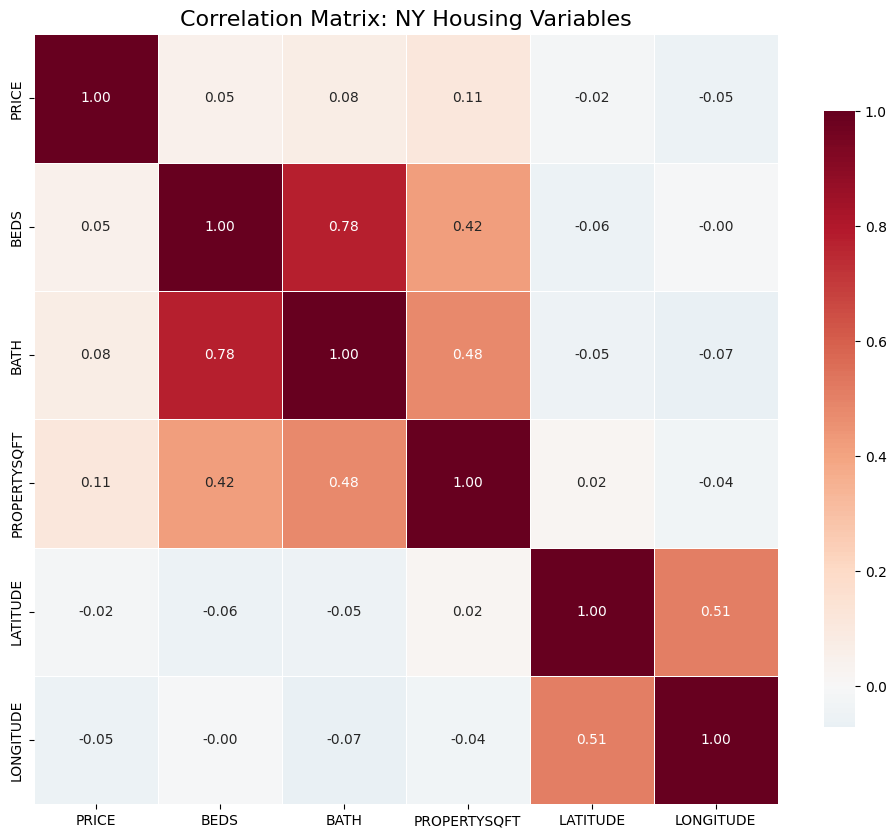

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. โหลดข้อมูล
df = pd.read_csv('../data/NY-House-Dataset.csv')

# 2. คัดเลือกเฉพาะตัวแปรที่เป็นตัวเลข (Numeric) เพื่อหาความสัมพันธ์
# เราจะเลือกตัวแปรหลักที่สำคัญต่อการตั้งราคา
numeric_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']
df_numeric = df[numeric_cols]

# 3. คำนวณค่า Correlation (ความสัมพันธ์ระหว่างตัวแปร)
corr_matrix = df_numeric.corr()

# 4. ตั้งค่าขนาดของกราฟ
plt.figure(figsize=(12, 10))

# 5. สร้าง Heatmap
# annot=True เพื่อแสดงตัวเลขในช่อง
# cmap='RdBu_r' เพื่อให้สีแดงคือบวก (สัมพันธ์กันมาก) และสีฟ้าคือลบ
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix: NY Housing Variables', fontsize=16)
plt.show()


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Feature Importance by XGBoost ---
        Feature  Importance
1          BATH    0.514188
3      LATITUDE    0.194252
4     LONGITUDE    0.163731
2  PROPERTYSQFT    0.089931
0          BEDS    0.037897


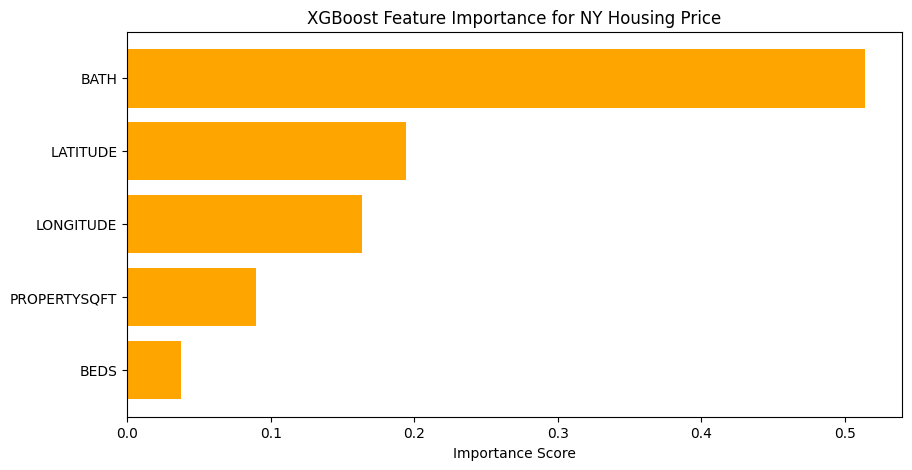

In [19]:
import pandas as pd
import sys
!{sys.executable} -m pip install xgboost
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูลที่ Clean แล้ว (สมมติว่าชื่อ df_cleaned)
# แยก Features (X) และ Target (y)
df_cleaned = pd.read_csv('../data/NY_House_Cleaned.csv')
X = df_cleaned[['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']]
y = df_cleaned['PRICE']

# 2. ใช้ XGBoost Regressor
# ปรับ hyperparameter เบื้องต้นเพื่อให้แม่นยำกว่า Random Forest
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X, y)

# 3. ดึงค่า Feature Importance (XGBoost มีวิธีคำนวณที่ฉลาดกว่า)
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importance by XGBoost ---")
print(importance_xgb)

# วาดกราฟ
plt.figure(figsize=(10, 5))
plt.barh(importance_xgb['Feature'], importance_xgb['Importance'], color='orange')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance for NY Housing Price')
plt.gca().invert_yaxis() # ให้ตัวที่สำคัญที่สุดอยู่บนสุด
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. เตรียมข้อมูล
X = df_cleaned[['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']]
y = df_cleaned['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. นิยามโมเดลที่ต้องการเทียบ
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# 3. รันและเก็บผล
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} R2 Score: {r2_score(y_test, y_pred):.4f}")

Random Forest R2 Score: 0.7615
XGBoost R2 Score: 0.7530



--- Feature Importance (ตัวแปรที่มีผลต่อราคามากที่สุด) ---
        Feature  Importance
3      LATITUDE    0.323781
1          BATH    0.272552
4     LONGITUDE    0.249712
2  PROPERTYSQFT    0.126669
0          BEDS    0.027286


C:\Users\Asus\AppData\Local\Temp\ipykernel_40552\31670003.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\

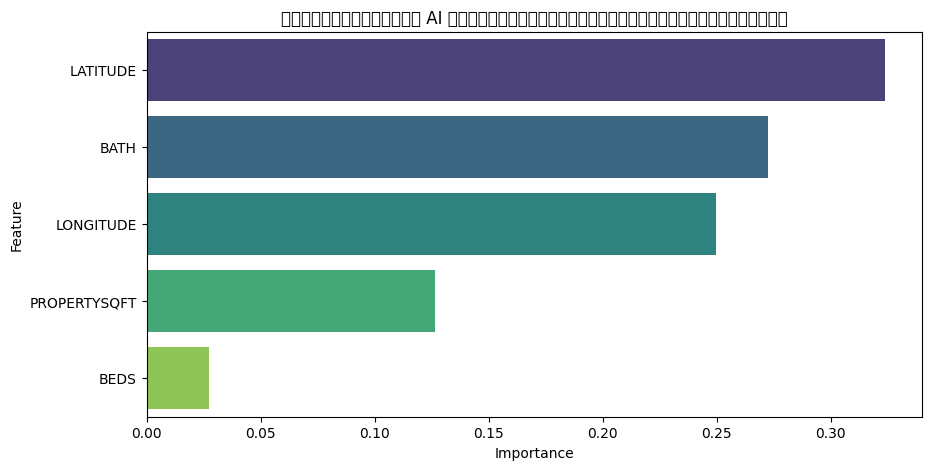

In [48]:
from sklearn.ensemble import RandomForestRegressor

# 1. กำหนด X (ปัจจัย) และ y (เป้าหมายคือราคา)

X = df_cleaned[['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']].fillna(0)
y = df_cleaned['PRICE'].fillna(0)

# 2. สร้างและฝึกโมเดลเบื้องต้น
model = RandomForestRegressor(n_estimators=1000, random_state=42)
model.fit(X, y)

# 3. ดึงค่าความสำคัญออกมา
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance (ตัวแปรที่มีผลต่อราคามากที่สุด) ---")
print(importance)

# วาดกราฟเปรียบเทียบ
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('ตัวแปรที่โมเดล AI ให้ความสำคัญสูงสุดในการพยากรณ์ราคา')
plt.show()

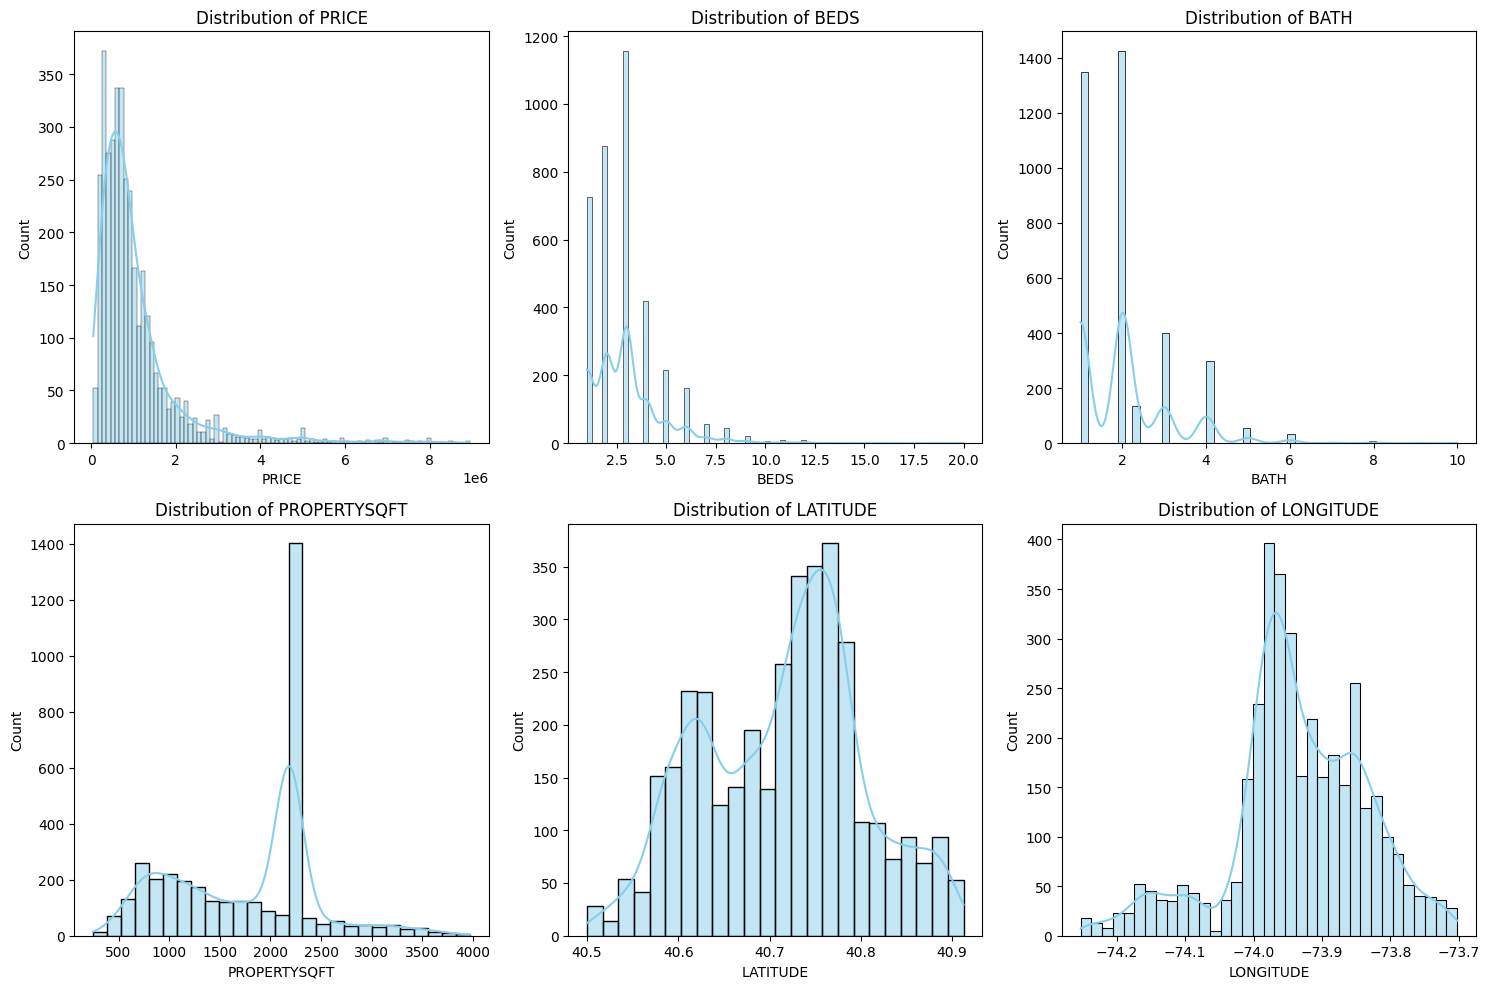

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# เลือกตัวแปรตัวเลขที่สำคัญ
numeric_features = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']

# สร้างตารางกราฟ
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_cleaned[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_40552\1528599423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y=col, palette='viridis', order=df_cleaned[col].value_counts().index)
C:\Users\Asus\AppData\Local\Temp\ipykernel_40552\1528599423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y=col, palette='viridis', order=df_cleaned[col].value_counts().index)


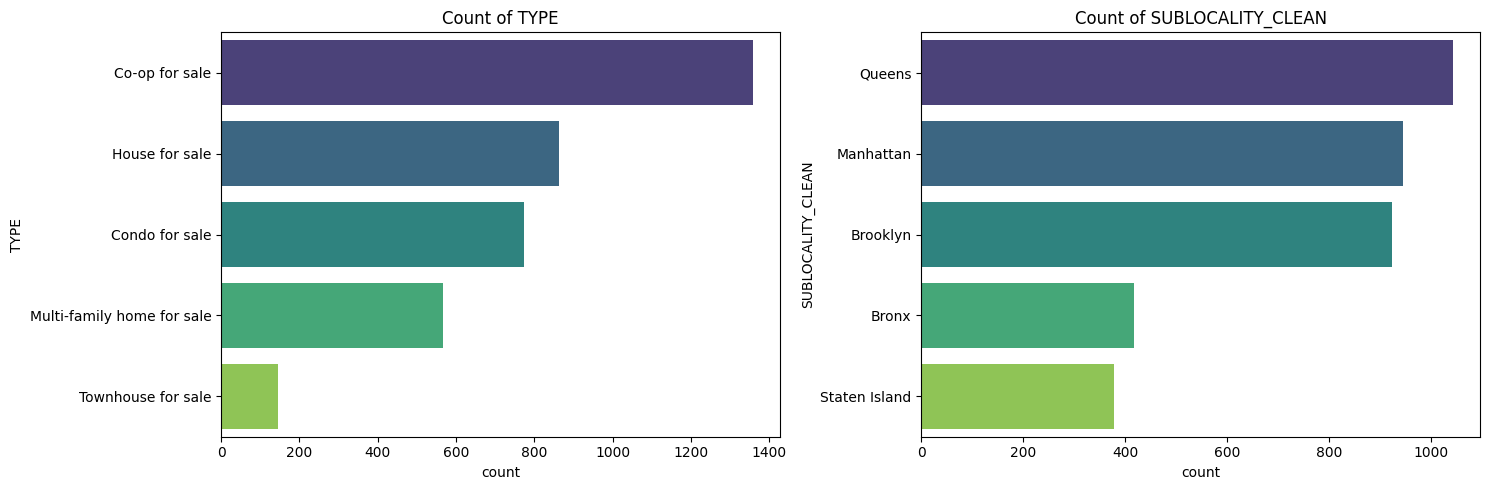

In [45]:
# ดูประเภทบ้านและย่าน (Borough)
categorical_features = ['TYPE', 'SUBLOCALITY_CLEAN']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_features):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=df_cleaned, y=col, palette='viridis', order=df_cleaned[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.tight_layout()

plt.show()